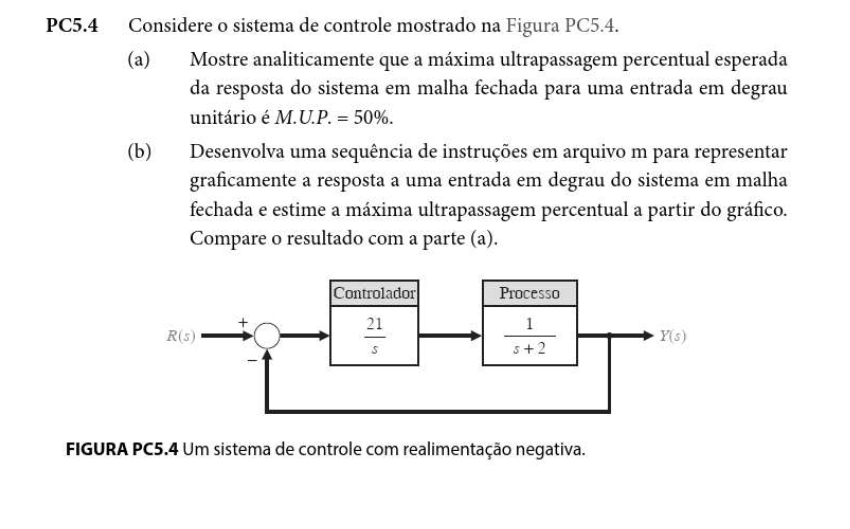

PROBLEMA PC5.4 - ANÁLISE DO MÁXIMO PERCENTUAL DE ULTRAPASSAGEM

(a) ANÁLISE ANALÍTICA:
--------------------------------------------------------------------------------

Sistema em Malha Aberta:
  G_c(s) = 21/s (Controlador)
  G_p(s) = 1/(s+2) (Processo)
  L(s) = G_c(s)*G_p(s) =
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     21
  ---------
  s^2 + 2 s

Sistema em Malha Fechada:
  T(s) = L(s)/(1 + L(s)) = Y(s)/R(s) =
<TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        21
  --------------
  s^2 + 2 s + 21

  Numerador: [21]
  Denominador: [array([ 1,  2, 21])]

────────────────────────────────────────────────────────────────────────────────
PARÂMETROS DO SISTEMA DE SEGUNDA ORDEM:
────────────────────────────────────────────────────────────────────────────────
  Frequência Natural: ωn = √21 = 4.582576 rad/s
  Amortecimento Relativo: ζ = 1/√21 = 0.218218

  √(1 - ζ²) = √(1 - 0.047619) = 0.975900
  e^(-ζπ/√(1-ζ²)) = e^(-0.218218*π/0.975

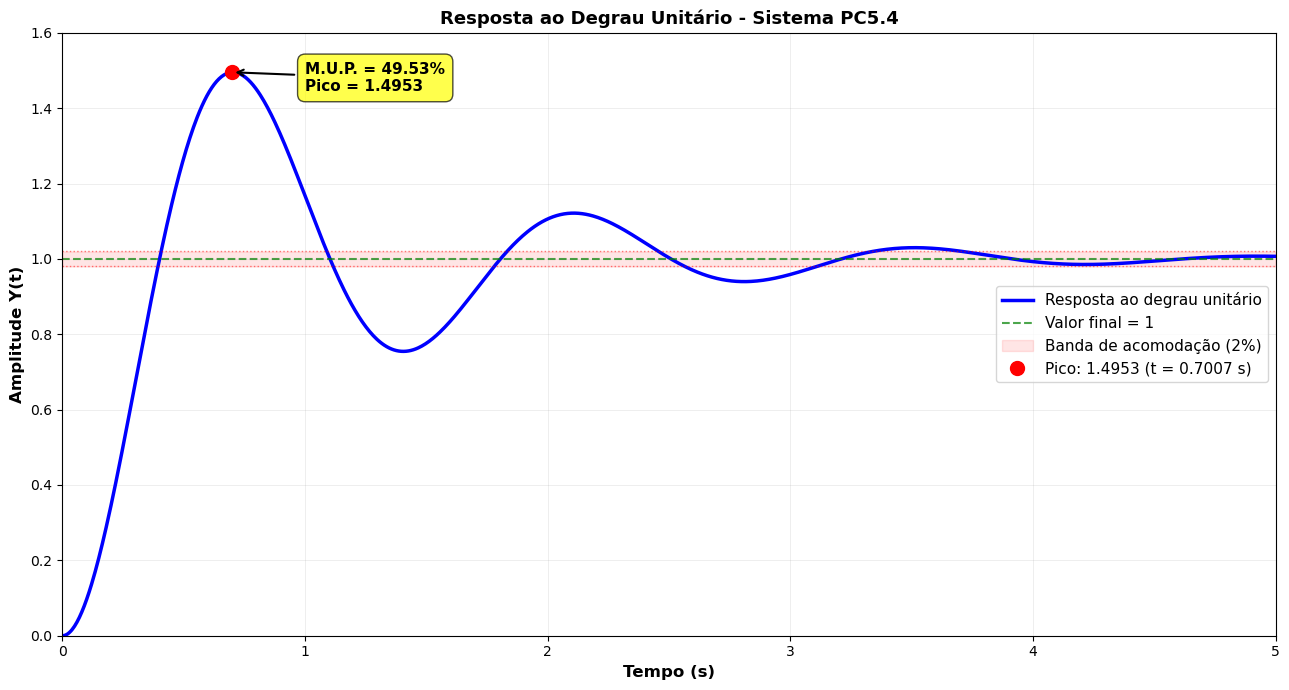


COMPARAÇÃO ENTRE ANÁLISE TEÓRICA E SIMULAÇÃO:

  Ultrapassagem percentual teórica (a):  49.54%
  Ultrapassagem percentual simulada (b): 49.53%
  Erro relativo:                         0.0017%

  Tempo de pico teórico:  0.702481 s
  Tempo de pico simulado: 0.700701 s

  Tempo de acomodação teórico (2%):  4.000000 s
  Tempo de acomodação simulado (2%): 4.319319 s

✓ Gráfico salvo como 'step_response_pc54.png'


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from scipy.optimize import fminbound

print("=" * 80)
print("PROBLEMA PC5.4 - ANÁLISE DO MÁXIMO PERCENTUAL DE ULTRAPASSAGEM")
print("=" * 80)

# Define the system components
# Controller: G_c(s) = 21/s
# Process: G_p(s) = 1/(s+2)
# Unit negative feedback

# Open-loop transfer function: L(s) = G_c(s)*G_p(s) = 21/(s(s+2))
num_L = [21]              # numerador
den_L = [1, 2, 0]         # denominador: s² + 2s = s(s+2)

L = ct.TransferFunction(num_L, den_L)

print("\n(a) ANÁLISE ANALÍTICA:")
print("-" * 80)
print("\nSistema em Malha Aberta:")
print("  G_c(s) = 21/s (Controlador)")
print("  G_p(s) = 1/(s+2) (Processo)")
print("  L(s) = G_c(s)*G_p(s) =")
print(L)

# Closed-loop transfer function: T(s) = L(s)/(1 + L(s))
T = ct.feedback(L)

print("\nSistema em Malha Fechada:")
print("  T(s) = L(s)/(1 + L(s)) = Y(s)/R(s) =")
print(T)

# Extract coefficients from the closed-loop transfer function
num_T, den_T = ct.tfdata(T)
num_T = num_T[0][0]
den_T = den_T[0]

print("\n  Numerador:", num_T)
print("  Denominador:", den_T)

# For a second-order system: T(s) = ωn²/(s² + 2ζωn*s + ωn²)
# We have: T(s) = 21/(s² + 2s + 21)
# Comparing: ωn² = 21  =>  ωn = √21
#            2ζωn = 2  =>  ζ = 1/√21

omega_n = np.sqrt(21)
zeta = 1 / np.sqrt(21)

print("\n" + "─" * 80)
print("PARÂMETROS DO SISTEMA DE SEGUNDA ORDEM:")
print("─" * 80)
print(f"  Frequência Natural: ωn = √21 = {omega_n:.6f} rad/s")
print(f"  Amortecimento Relativo: ζ = 1/√21 = {zeta:.6f}")

# Percent overshoot formula for second-order system
# M.U.P. = e^(-ζπ/√(1-ζ²)) × 100%
if zeta < 1:  # Underdamped system
    sqrt_term = np.sqrt(1 - zeta**2)
    exp_term = np.exp(-zeta * np.pi / sqrt_term)
    percent_overshoot = exp_term * 100
    
    print(f"\n  √(1 - ζ²) = √(1 - {zeta**2:.6f}) = {sqrt_term:.6f}")
    print(f"  e^(-ζπ/√(1-ζ²)) = e^(-{zeta:.6f}*π/{sqrt_term:.6f})")
    print(f"                   = e^({-zeta*np.pi/sqrt_term:.6f})")
    print(f"                   = {exp_term:.6f}")
    print(f"\n  MÁXIMA ULTRAPASSAGEM PERCENTUAL (M.U.P.):")
    print(f"  M.U.P. = {exp_term:.6f} × 100% = {percent_overshoot:.2f}%")
else:
    percent_overshoot = 0
    print(f"\n  Sistema superamortecido (ζ ≥ 1): sem ultrapassagem")

# Calculate other important parameters
natural_freq_hz = omega_n / (2 * np.pi)
damping_freq = omega_n * np.sqrt(1 - zeta**2) if zeta < 1 else 0
settling_time_2pct = 4 / (zeta * omega_n)
peak_time = np.pi / (omega_n * np.sqrt(1 - zeta**2)) if zeta < 1 else float('inf')

print(f"\n" + "─" * 80)
print("OUTROS PARÂMETROS DO SISTEMA:")
print("─" * 80)
print(f"  Frequência natural: {natural_freq_hz:.4f} Hz")
if zeta < 1:
    print(f"  Frequência de oscilação: {damping_freq:.4f} rad/s")
    print(f"  Tempo de pico (máxima ultrapassagem): t_p = {peak_time:.6f} s")
print(f"  Tempo de acomodação (2%): t_s = {settling_time_2pct:.6f} s")

# Part (b): Plot the step response
print("\n" + "=" * 80)
print("(b) RESPOSTA AO DEGRAU E ESTIMATIVA GRÁFICA")
print("=" * 80)

# Calculate step response
t = np.linspace(0, 5, 1000)
t_out, y = ct.step_response(T, T=t)

# Find the peak (maximum overshoot)
peak_idx = np.argmax(y)
peak_value = y[peak_idx]
peak_time_sim = t_out[peak_idx]

# Calculate percent overshoot from simulation
percent_overshoot_sim = (peak_value - 1) * 100  # For unit step, final value is 1

print(f"\nA partir da simulação:")
print(f"  Valor de pico: y_max = {peak_value:.6f}")
print(f"  Tempo de pico: t_p = {peak_time_sim:.6f} s")
print(f"  Ultrapassagem percentual: M.U.P. = {percent_overshoot_sim:.2f}%")

# Find settling time (2% criterion)
final_value = y[-1]
settling_time_idx = None
for i in range(len(y) - 1, -1, -1):
    if abs(y[i] - final_value) > 0.02:
        settling_time_idx = i
        break

if settling_time_idx:
    settling_time_sim = t_out[settling_time_idx]
else:
    settling_time_sim = 0

print(f"  Tempo de acomodação (2%): t_s ≈ {settling_time_sim:.6f} s")

# Create the plot
fig, ax = plt.subplots(figsize=(13, 7))

# Plot step response
ax.plot(t_out, y, 'b-', linewidth=2.5, label='Resposta ao degrau unitário')

# Plot reference level (final value = 1)
ax.axhline(y=1, color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='Valor final = 1')

# Plot overshoot band (100% ± 2%)
ax.axhline(y=1.02, color='r', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(y=0.98, color='r', linestyle=':', linewidth=1, alpha=0.5)
ax.fill_between(t_out, 0.98, 1.02, alpha=0.1, color='red', label='Banda de acomodação (2%)')

# Mark the peak
if peak_time_sim < t_out[-1]:
    ax.plot(peak_time_sim, peak_value, 'ro', markersize=10, label=f'Pico: {peak_value:.4f} (t = {peak_time_sim:.4f} s)')
    ax.annotate(f'M.U.P. = {percent_overshoot_sim:.2f}%\nPico = {peak_value:.4f}', 
                xy=(peak_time_sim, peak_value), 
                xytext=(peak_time_sim + 0.3, peak_value - 0.05),
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1.5))

# Formatting
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_xlabel('Tempo (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Amplitude Y(t)', fontsize=12, fontweight='bold')
ax.set_title('Resposta ao Degrau Unitário - Sistema PC5.4', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='right')
ax.set_xlim(0, 5)
ax.set_ylim(0, 1.6)

plt.tight_layout()
plt.savefig('step_response_pc54.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("COMPARAÇÃO ENTRE ANÁLISE TEÓRICA E SIMULAÇÃO:")
print("=" * 80)
print(f"\n  Ultrapassagem percentual teórica (a):  {percent_overshoot:.2f}%")
print(f"  Ultrapassagem percentual simulada (b): {percent_overshoot_sim:.2f}%")
print(f"  Erro relativo:                         {abs(percent_overshoot - percent_overshoot_sim):.4f}%")

print(f"\n  Tempo de pico teórico:  {peak_time:.6f} s")
print(f"  Tempo de pico simulado: {peak_time_sim:.6f} s")

print(f"\n  Tempo de acomodação teórico (2%):  {settling_time_2pct:.6f} s")
print(f"  Tempo de acomodação simulado (2%): {settling_time_sim:.6f} s")

print("\n✓ Gráfico salvo como 'step_response_pc54.png'")
print("=" * 80)